In [2]:
print("Dividend Puzzle Analyzer")
print("Day 2 - Data Analysis Setup")

Dividend Puzzle Analyzer
Day 2 - Data Analysis Setup


In [3]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [4]:
import numpy as np

print("NumPy version:", np.__version__)

NumPy version: 2.4.6


In [5]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is working!


In [6]:
import seaborn as sns

print("Seaborn is working!")

Seaborn is working!


In [7]:
import pandas as pd

companies = pd.read_csv("../datasets/raw/companies.csv")

companies

,company,ticker,start_year,end_year
0,Apple,AAPL,2015,2025
1,Microsoft,MSFT,2015,2025
2,Coca-Cola,KO,2015,2025
3,PepsiCo,PEP,2015,2025
4,Johnson & Johnson,JNJ,2015,2025
5,Procter & Gamble,PG,2015,2025
6,McDonald's,MCD,2015,2025
7,Walmart,WMT,2015,2025
8,Exxon Mobil,XOM,2015,2025
9,Verizon,VZ,2015,2025


In [8]:
print("Number of companies:", len(companies))

Number of companies: 10


In [9]:
print(companies.columns.tolist())

['company', 'ticker', 'start_year', 'end_year']


In [10]:
companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   company     10 non-null     str  
 1   ticker      10 non-null     str  
 2   start_year  10 non-null     int64
 3   end_year    10 non-null     int64
dtypes: int64(2), str(2)
memory usage: 452.0 bytes


In [11]:
import yfinance as yf

apple = yf.Ticker("AAPL")

print("Company:", apple.info.get("longName"))

Company: Apple Inc.


In [12]:
apple_prices = apple.history(
    start="2015-01-01",
    end="2026-01-01"
)

apple_prices.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00-05:00,24.627201,24.638257,23.733998,24.171757,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,23.941821,24.021413,23.305082,23.490797,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,23.554918,23.751688,23.132636,23.493013,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,23.700830,23.921919,23.590285,23.822430,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,24.149645,24.795227,24.032466,24.737743,237458000,0.0,0.0


In [13]:
print("Rows:", len(apple_prices))
print("Columns:", len(apple_prices.columns))

Rows: 2766
Columns: 7


In [14]:
print("First date:", apple_prices.index.min())
print("Last date:", apple_prices.index.max())


First date: 2015-01-02 00:00:00-05:00
Last date: 2025-12-31 00:00:00-05:00


In [15]:
apple_dividends = apple.dividends

apple_dividends.head(10)

Date
1987-05-11 09:30:00-04:00    0.000536
1987-08-10 09:30:00-04:00    0.000536
1987-11-17 09:30:00-05:00    0.000714
1988-02-12 09:30:00-05:00    0.000714
1988-05-16 09:30:00-04:00    0.000714
1988-08-15 09:30:00-04:00    0.000714
1988-11-21 09:30:00-05:00    0.000893
1989-02-17 09:30:00-05:00    0.000893
1989-05-22 09:30:00-04:00    0.000893
1989-08-21 09:30:00-04:00    0.000893
Name: Dividends, dtype: float64

In [16]:
annual_dividends = apple_dividends.resample("YE").sum()

annual_dividends

Date
1987-12-31 00:00:00-05:00    0.001786
1988-12-31 00:00:00-05:00    0.003035
1989-12-31 00:00:00-05:00    0.003661
1990-12-31 00:00:00-05:00    0.004017
1991-12-31 00:00:00-05:00    0.004284
1992-12-31 00:00:00-05:00    0.004284
1993-12-31 00:00:00-05:00    0.004284
1994-12-31 00:00:00-05:00    0.004284
1995-12-31 00:00:00-05:00    0.004284
1996-12-31 00:00:00-05:00    0.000000
1997-12-31 00:00:00-05:00    0.000000
1998-12-31 00:00:00-05:00    0.000000
1999-12-31 00:00:00-05:00    0.000000
2000-12-31 00:00:00-05:00    0.000000
2001-12-31 00:00:00-05:00    0.000000
2002-12-31 00:00:00-05:00    0.000000
2003-12-31 00:00:00-05:00    0.000000
2004-12-31 00:00:00-05:00    0.000000
2005-12-31 00:00:00-05:00    0.000000
2006-12-31 00:00:00-05:00    0.000000
2007-12-31 00:00:00-05:00    0.000000
2008-12-31 00:00:00-05:00    0.000000
2009-12-31 00:00:00-05:00    0.000000
2010-12-31 00:00:00-05:00    0.000000
2011-12-31 00:00:00-05:00    0.000000
2012-12-31 00:00:00-05:00    0.189286
2013-12

In [17]:
annual_dividends = annual_dividends.reset_index()

annual_dividends.columns = ["date", "dividend_per_share"]

annual_dividends["year"] = annual_dividends["date"].dt.year

annual_dividends = annual_dividends[
    ["year", "dividend_per_share"]
]

annual_dividends

,year,dividend_per_share
0,1987,0.001786
1,1988,0.003035
2,1989,0.003661
3,1990,0.004017
4,1991,0.004284
5,1992,0.004284
6,1993,0.004284
7,1994,0.004284
8,1995,0.004284
9,1996,0.000000


In [18]:
annual_dividends["company"] = "Apple"
annual_dividends["ticker"] = "AAPL"

annual_dividends

,year,dividend_per_share,company,ticker
0,1987,0.001786,Apple,AAPL
1,1988,0.003035,Apple,AAPL
2,1989,0.003661,Apple,AAPL
3,1990,0.004017,Apple,AAPL
4,1991,0.004284,Apple,AAPL
5,1992,0.004284,Apple,AAPL
6,1993,0.004284,Apple,AAPL
7,1994,0.004284,Apple,AAPL
8,1995,0.004284,Apple,AAPL
9,1996,0.000000,Apple,AAPL


In [20]:
apple_prices = apple_prices.reset_index()

apple_prices["year"] = apple_prices["Date"].dt.year

year_end_prices = (
    apple_prices
    .sort_values("Date")
    .groupby("year")
    .tail(1)
)

year_end_prices = year_end_prices[
    ["year", "Close"]
]

year_end_prices

,year,Close
251,2015,23.668432
503,2016,26.622360
754,2017,39.524700
1005,2018,37.394245
1257,2019,70.659363
1510,2020,128.816742
1762,2021,173.449448
2013,2022,127.651520
2263,2023,190.211014
2515,2024,248.615799


In [21]:
apple_data = pd.merge(
    annual_dividends,
    year_end_prices,
    on="year",
    how="left"
)

apple_data

,year,dividend_per_share,company,ticker,Close
0,1987,0.001786,Apple,AAPL,NaN
1,1988,0.003035,Apple,AAPL,NaN
2,1989,0.003661,Apple,AAPL,NaN
3,1990,0.004017,Apple,AAPL,NaN
4,1991,0.004284,Apple,AAPL,NaN
5,1992,0.004284,Apple,AAPL,NaN
6,1993,0.004284,Apple,AAPL,NaN
7,1994,0.004284,Apple,AAPL,NaN
8,1995,0.004284,Apple,AAPL,NaN
9,1996,0.000000,Apple,AAPL,NaN


In [22]:
apple_data["dividend_yield"] = (
    apple_data["dividend_per_share"]
    / apple_data["Close"]
) * 100

apple_data

,year,dividend_per_share,company,ticker,Close,dividend_yield
0,1987,0.001786,Apple,AAPL,NaN,NaN
1,1988,0.003035,Apple,AAPL,NaN,NaN
2,1989,0.003661,Apple,AAPL,NaN,NaN
3,1990,0.004017,Apple,AAPL,NaN,NaN
4,1991,0.004284,Apple,AAPL,NaN,NaN
5,1992,0.004284,Apple,AAPL,NaN,NaN
6,1993,0.004284,Apple,AAPL,NaN,NaN
7,1994,0.004284,Apple,AAPL,NaN,NaN
8,1995,0.004284,Apple,AAPL,NaN,NaN
9,1996,0.000000,Apple,AAPL,NaN,NaN


In [23]:
apple_data = apple_data.rename(
    columns={"Close": "year_end_price"}
)

apple_data

,year,dividend_per_share,company,ticker,year_end_price,dividend_yield
0,1987,0.001786,Apple,AAPL,NaN,NaN
1,1988,0.003035,Apple,AAPL,NaN,NaN
2,1989,0.003661,Apple,AAPL,NaN,NaN
3,1990,0.004017,Apple,AAPL,NaN,NaN
4,1991,0.004284,Apple,AAPL,NaN,NaN
5,1992,0.004284,Apple,AAPL,NaN,NaN
6,1993,0.004284,Apple,AAPL,NaN,NaN
7,1994,0.004284,Apple,AAPL,NaN,NaN
8,1995,0.004284,Apple,AAPL,NaN,NaN
9,1996,0.000000,Apple,AAPL,NaN,NaN


In [24]:
apple_data.to_csv(
    "../datasets/raw/AAPL_market_dividend_data.csv",
    index=False
)

In [25]:
import pandas as pd
import yfinance as yf

In [26]:
companies = pd.read_csv("../datasets/raw/companies.csv")

companies

,company,ticker,start_year,end_year
0,Apple,AAPL,2015,2025
1,Microsoft,MSFT,2015,2025
2,Coca-Cola,KO,2015,2025
3,PepsiCo,PEP,2015,2025
4,Johnson & Johnson,JNJ,2015,2025
5,Procter & Gamble,PG,2015,2025
6,McDonald's,MCD,2015,2025
7,Walmart,WMT,2015,2025
8,Exxon Mobil,XOM,2015,2025
9,Verizon,VZ,2015,2025


In [27]:
all_company_data = []

for _, row in companies.iterrows():

    company = row["company"]
    ticker = row["ticker"]

    print(f"Collecting data for {company} ({ticker})...")

    stock = yf.Ticker(ticker)

    # Download historical price and dividend data
    prices = stock.history(
        start="2015-01-01",
        end="2026-01-01",
        auto_adjust=False
    )

    # Skip if no data was returned
    if prices.empty:
        print(f"No data found for {ticker}")
        continue

    # Convert index to normal column
    prices = prices.reset_index()

    # Create year column
    prices["year"] = prices["Date"].dt.year

    # Year-end closing price
    year_end_prices = (
        prices
        .sort_values("Date")
        .groupby("year")
        .tail(1)
    )

    year_end_prices = year_end_prices[
        ["year", "Close"]
    ].rename(
        columns={"Close": "year_end_price"}
    )

    # Annual dividends
    dividends = prices[
        ["Date", "Dividends"]
    ].copy()

    dividends["year"] = dividends["Date"].dt.year

    annual_dividends = (
        dividends
        .groupby("year")["Dividends"]
        .sum()
        .reset_index()
    )

    annual_dividends = annual_dividends.rename(
        columns={"Dividends": "dividend_per_share"}
    )

    # Merge price and dividend data
    company_data = pd.merge(
        year_end_prices,
        annual_dividends,
        on="year",
        how="left"
    )

    # Fill missing dividends with 0
    company_data["dividend_per_share"] = (
        company_data["dividend_per_share"].fillna(0)
    )

    # Add company information
    company_data["company"] = company
    company_data["ticker"] = ticker

    # Calculate dividend yield
    company_data["dividend_yield"] = (
        company_data["dividend_per_share"]
        / company_data["year_end_price"]
    ) * 100

    all_company_data.append(company_data)

print("Data collection completed.")

Data collection completed.


In [28]:
all_data = pd.concat(
    all_company_data,
    ignore_index=True
)

all_data.head(20)

,year,year_end_price,dividend_per_share,company,ticker,dividend_yield
0,2015,26.315001,0.5075,Apple,AAPL,1.928558
1,2016,28.955000,0.5575,Apple,AAPL,1.925401
2,2017,42.307499,0.6150,Apple,AAPL,1.453643
3,2018,39.435001,0.7050,Apple,AAPL,1.787752
4,2019,73.412498,0.7600,Apple,AAPL,1.035246
5,2020,132.690002,0.8075,Apple,AAPL,0.608561
6,2021,177.570007,0.8650,Apple,AAPL,0.487132
7,2022,129.929993,0.9100,Apple,AAPL,0.700377
8,2023,192.529999,0.9500,Apple,AAPL,0.493430
9,2024,250.419998,0.9900,Apple,AAPL,0.395336


In [29]:
print("Number of companies:", all_data["ticker"].nunique())

Number of companies: 10


In [30]:
print(
    "Years:",
    sorted(all_data["year"].unique())
)

Years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


In [31]:
print("Total rows:", len(all_data))

Total rows: 110


In [32]:
all_data.isnull().sum()

year                  0
year_end_price        0
dividend_per_share    0
company               0
ticker                0
dividend_yield        0
dtype: int64

In [33]:
all_data

,year,year_end_price,dividend_per_share,company,ticker,dividend_yield
0,2015,26.315001,0.5075,Apple,AAPL,1.928558
1,2016,28.955000,0.5575,Apple,AAPL,1.925401
2,2017,42.307499,0.6150,Apple,AAPL,1.453643
3,2018,39.435001,0.7050,Apple,AAPL,1.787752
4,2019,73.412498,0.7600,Apple,AAPL,1.035246
...,...,...,...,...,...,...
105,2021,51.959999,2.5240,Verizon,VZ,4.857583
106,2022,39.400002,2.5730,Verizon,VZ,6.530457
107,2023,37.700001,2.6240,Verizon,VZ,6.960212
108,2024,39.990002,2.6730,Verizon,VZ,6.684171


In [34]:
all_data = all_data[
    [
        "company",
        "ticker",
        "year",
        "year_end_price",
        "dividend_per_share",
        "dividend_yield"
    ]
]

all_data.head()

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield
0,Apple,AAPL,2015,26.315001,0.5075,1.928558
1,Apple,AAPL,2016,28.955000,0.5575,1.925401
2,Apple,AAPL,2017,42.307499,0.6150,1.453643
3,Apple,AAPL,2018,39.435001,0.7050,1.787752
4,Apple,AAPL,2019,73.412498,0.7600,1.035246


In [35]:
all_data = all_data.sort_values(
    ["ticker", "year"]
).reset_index(drop=True)

all_data.head(20)

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield
0,Apple,AAPL,2015,26.315001,0.5075,1.928558
1,Apple,AAPL,2016,28.955000,0.5575,1.925401
2,Apple,AAPL,2017,42.307499,0.6150,1.453643
3,Apple,AAPL,2018,39.435001,0.7050,1.787752
4,Apple,AAPL,2019,73.412498,0.7600,1.035246
5,Apple,AAPL,2020,132.690002,0.8075,0.608561
6,Apple,AAPL,2021,177.570007,0.8650,0.487132
7,Apple,AAPL,2022,129.929993,0.9100,0.700377
8,Apple,AAPL,2023,192.529999,0.9500,0.493430
9,Apple,AAPL,2024,250.419998,0.9900,0.395336


In [36]:
all_data.to_csv(
    "../datasets/raw/all_companies_market_dividend_data.csv",
    index=False
)

In [37]:
import pandas as pd

data = pd.read_csv(
    "../datasets/raw/all_companies_market_dividend_data.csv"
)

data.head()

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield
0,Apple,AAPL,2015,26.315001,0.5075,1.928558
1,Apple,AAPL,2016,28.955000,0.5575,1.925401
2,Apple,AAPL,2017,42.307499,0.6150,1.453643
3,Apple,AAPL,2018,39.435001,0.7050,1.787752
4,Apple,AAPL,2019,73.412498,0.7600,1.035246


In [38]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 110
Columns: 6


In [39]:
print(data.columns.tolist())

['company', 'ticker', 'year', 'year_end_price', 'dividend_per_share', 'dividend_yield']


In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   company             110 non-null    str    
 1   ticker              110 non-null    str    
 2   year                110 non-null    int64  
 3   year_end_price      110 non-null    float64
 4   dividend_per_share  110 non-null    float64
 5   dividend_yield      110 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 5.3 KB


In [41]:
data.isnull().sum()

company               0
ticker                0
year                  0
year_end_price        0
dividend_per_share    0
dividend_yield        0
dtype: int64

In [42]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [43]:
duplicates = data.duplicated(
    subset=["ticker", "year"]
).sum()

print("Duplicate company-year records:", duplicates)

Duplicate company-year records: 0


In [44]:
print("Companies:", data["ticker"].nunique())
print(data["ticker"].unique())

Companies: 10
<StringArray>
['AAPL', 'JNJ', 'KO', 'MCD', 'MSFT', 'PEP', 'PG', 'VZ', 'WMT', 'XOM']
Length: 10, dtype: str


In [45]:
print(
    "Minimum year:",
    data["year"].min()
)

print(
    "Maximum year:",
    data["year"].max()
)

Minimum year: 2015
Maximum year: 2025


In [46]:
print(
    "Negative stock prices:",
    (data["year_end_price"] < 0).sum()
)

Negative stock prices: 0


In [47]:
print(
    "Negative dividends:",
    (data["dividend_per_share"] < 0).sum()
)

Negative dividends: 0


In [48]:
print(
    "Negative dividend yields:",
    (data["dividend_yield"] < 0).sum()
)

Negative dividend yields: 0


In [49]:
data.describe()

,year,year_end_price,dividend_per_share,dividend_yield
count,110.00000,110.000000,110.000000,110.000000
mean,2020.00000,122.894288,2.771805,2.748797
std,3.17675,87.594815,1.513528,1.435949
min,2015.00000,20.433332,0.507500,0.378871
25%,2017.00000,55.382499,1.567500,1.985288
50%,2020.00000,103.674999,2.752000,2.677590
75%,2023.00000,157.619999,3.722000,3.242865
max,2025.00000,483.619995,7.170000,8.442503


In [50]:
data["year"] = pd.to_numeric(
    data["year"],
    errors="coerce"
)

data["year_end_price"] = pd.to_numeric(
    data["year_end_price"],
    errors="coerce"
)

data["dividend_per_share"] = pd.to_numeric(
    data["dividend_per_share"],
    errors="coerce"
)

data["dividend_yield"] = pd.to_numeric(
    data["dividend_yield"],
    errors="coerce"
)

In [51]:
data = data.drop_duplicates()

print("Rows after removing duplicates:", len(data))

Rows after removing duplicates: 110


In [52]:
data[data.isnull().any(axis=1)]

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield


In [53]:
data = data.dropna(
    subset=[
        "ticker",
        "year",
        "year_end_price"
    ]
)

In [54]:
data["dividend_yield"] = (
    data["dividend_per_share"]
    / data["year_end_price"]
) * 100

In [55]:
data["dividend_yield"] = data["dividend_yield"].round(2)

In [56]:
data = data.sort_values(
    ["ticker", "year"]
).reset_index(drop=True)

In [57]:
print("Final rows:", len(data))
print("Final columns:", len(data.columns))
print("Companies:", data["ticker"].nunique())
print("Duplicate rows:", data.duplicated().sum())
print("\nMissing values:")
print(data.isnull().sum())

Final rows: 110
Final columns: 6
Companies: 10
Duplicate rows: 0

Missing values:
company               0
ticker                0
year                  0
year_end_price        0
dividend_per_share    0
dividend_yield        0
dtype: int64


In [58]:
data.to_csv(
    "../datasets/processed/dividend_analysis_clean.csv",
    index=False
)

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
data = pd.read_csv(
    "../datasets/processed/dividend_analysis_clean.csv"
)

data.head()

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield
0,Apple,AAPL,2015,26.315001,0.5075,1.93
1,Apple,AAPL,2016,28.955000,0.5575,1.93
2,Apple,AAPL,2017,42.307499,0.6150,1.45
3,Apple,AAPL,2018,39.435001,0.7050,1.79
4,Apple,AAPL,2019,73.412498,0.7600,1.04


In [61]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
print("Companies:", data["ticker"].nunique())

Rows: 110
Columns: 6
Companies: 10


In [62]:
data.describe()

,year,year_end_price,dividend_per_share,dividend_yield
count,110.00000,110.000000,110.000000,110.000000
mean,2020.00000,122.894288,2.771805,2.749182
std,3.17675,87.594815,1.513528,1.435828
min,2015.00000,20.433332,0.507500,0.380000
25%,2017.00000,55.382499,1.567500,1.987500
50%,2020.00000,103.674999,2.752000,2.675000
75%,2023.00000,157.619999,3.722000,3.245000
max,2025.00000,483.619995,7.170000,8.440000


In [63]:
company_dividend = (
    data.groupby("ticker")["dividend_per_share"]
    .mean()
    .sort_values(ascending=False)
)

company_dividend

ticker
MCD     5.084545
PEP     4.088364
JNJ     4.007273
XOM     3.420000
PG      3.258818
VZ      2.472727
MSFT    2.196364
KO      1.660000
AAPL    0.790682
WMT     0.739273
Name: dividend_per_share, dtype: float64

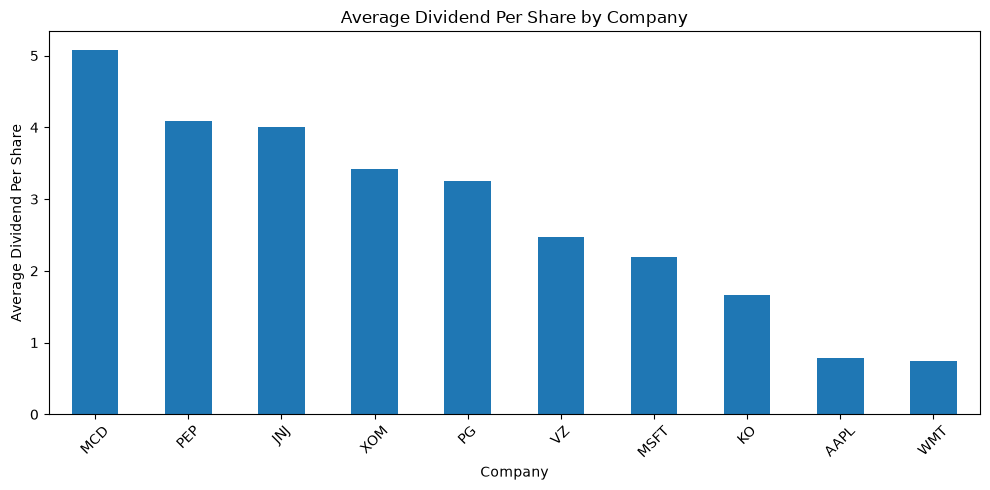

In [64]:
company_dividend.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Dividend Per Share by Company")
plt.xlabel("Company")
plt.ylabel("Average Dividend Per Share")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
company_yield = (
    data.groupby("ticker")["dividend_yield"]
    .mean()
    .sort_values(ascending=False)
)

company_yield

ticker
VZ      5.230909
XOM     4.385455
KO      3.056364
PEP     2.933636
JNJ     2.697273
PG      2.679091
MCD     2.373636
WMT     1.816364
MSFT    1.300000
AAPL    1.019091
Name: dividend_yield, dtype: float64

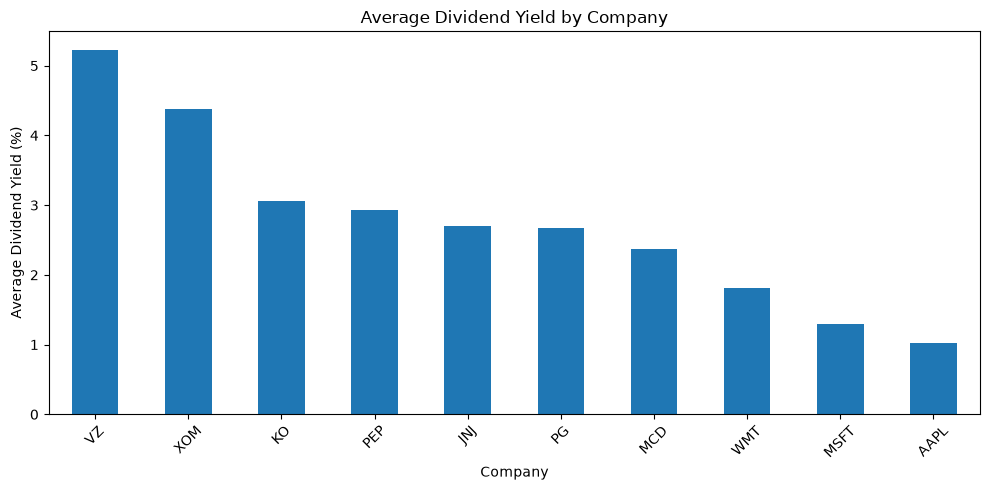

In [66]:
company_yield.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Dividend Yield by Company")
plt.xlabel("Company")
plt.ylabel("Average Dividend Yield (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

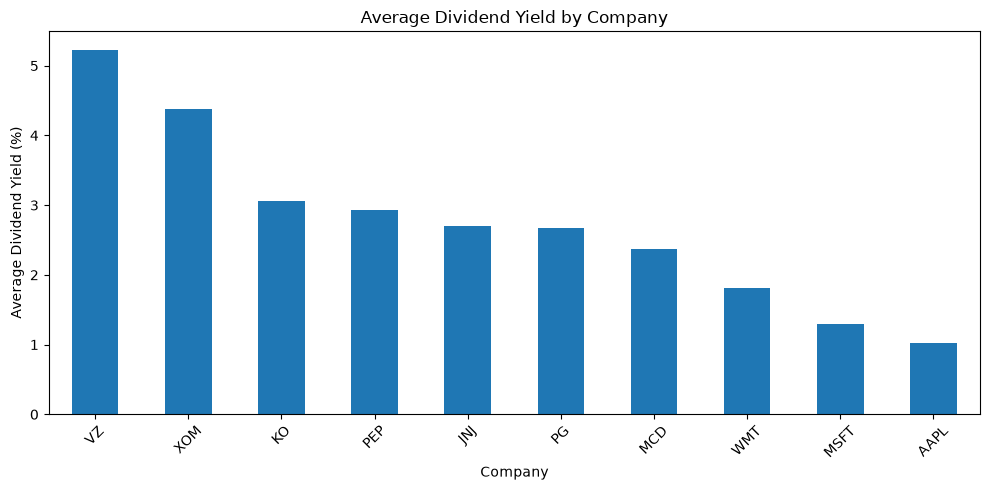

In [67]:
company_yield.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Dividend Yield by Company")
plt.xlabel("Company")
plt.ylabel("Average Dividend Yield (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
yearly_dividend = (
    data.groupby("year")["dividend_per_share"]
    .mean()
)

yearly_dividend

year
2015    2.065283
2016    2.174217
2017    2.280700
2018    2.444133
2019    2.603867
2020    2.737350
2021    2.868133
2022    3.032367
2023    3.225500
2024    3.433700
2025    3.624600
Name: dividend_per_share, dtype: float64

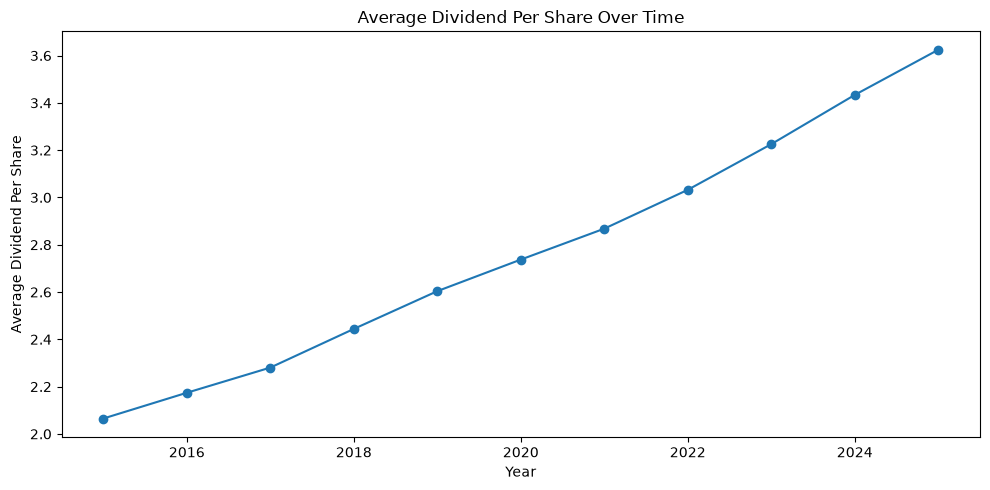

In [69]:
yearly_dividend.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Dividend Per Share Over Time")
plt.xlabel("Year")
plt.ylabel("Average Dividend Per Share")
plt.tight_layout()
plt.show()

In [70]:
yearly_price = (
    data.groupby("year")["year_end_price"]
    .mean()
)

yearly_price

year
2015     66.954833
2016     72.487500
2017     86.685416
2018     85.283501
2019    106.230582
2020    121.737001
2021    151.091003
2022    140.272333
2023    158.736002
2024    172.631000
2025    189.727999
Name: year_end_price, dtype: float64

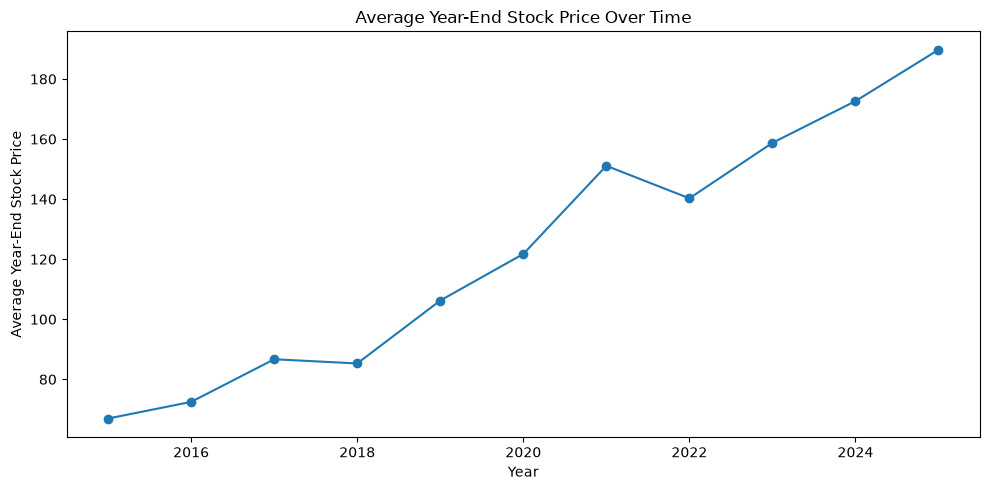

In [71]:
yearly_price.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Year-End Stock Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Year-End Stock Price")
plt.tight_layout()
plt.show()

In [72]:
yearly_yield = (
    data.groupby("year")["dividend_yield"]
    .mean()
)

yearly_yield

year
2015    3.088
2016    2.984
2017    2.689
2018    2.940
2019    2.589
2020    2.852
2021    2.503
2022    2.541
2023    2.700
2024    2.703
2025    2.652
Name: dividend_yield, dtype: float64

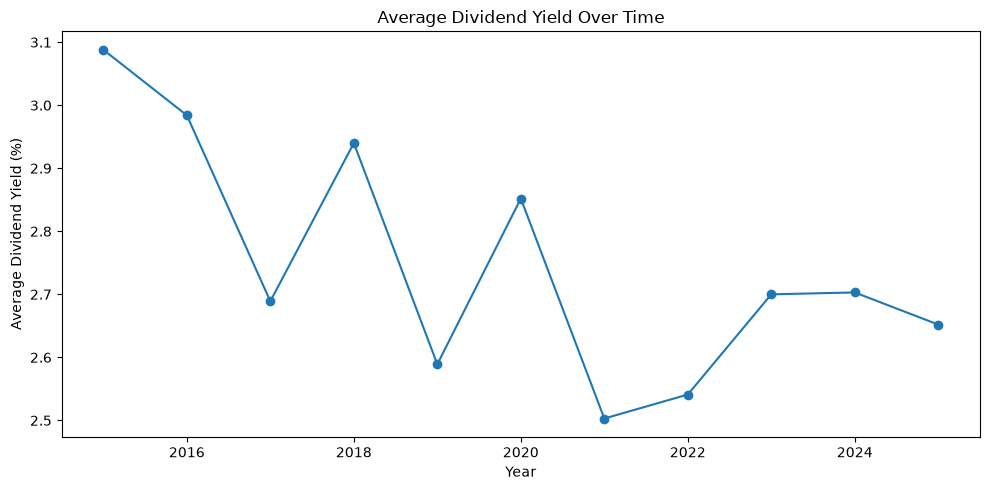

In [73]:
yearly_yield.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Average Dividend Yield Over Time")
plt.xlabel("Year")
plt.ylabel("Average Dividend Yield (%)")
plt.tight_layout()
plt.show()

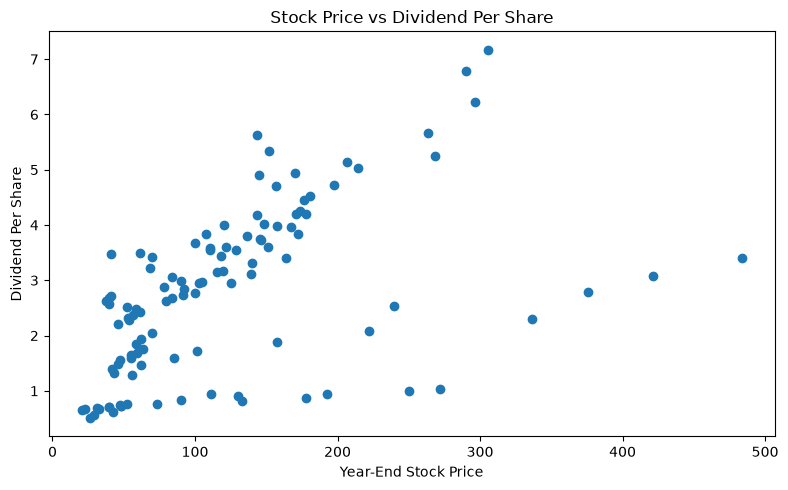

In [74]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["year_end_price"],
    data["dividend_per_share"]
)

plt.title("Stock Price vs Dividend Per Share")
plt.xlabel("Year-End Stock Price")
plt.ylabel("Dividend Per Share")

plt.tight_layout()
plt.show()

In [75]:
correlation = data[
    [
        "year_end_price",
        "dividend_per_share",
        "dividend_yield"
    ]
].corr()

correlation

,year_end_price,dividend_per_share,dividend_yield
year_end_price,1.000000,0.515728,-0.486644
dividend_per_share,0.515728,1.000000,0.233200
dividend_yield,-0.486644,0.233200,1.000000


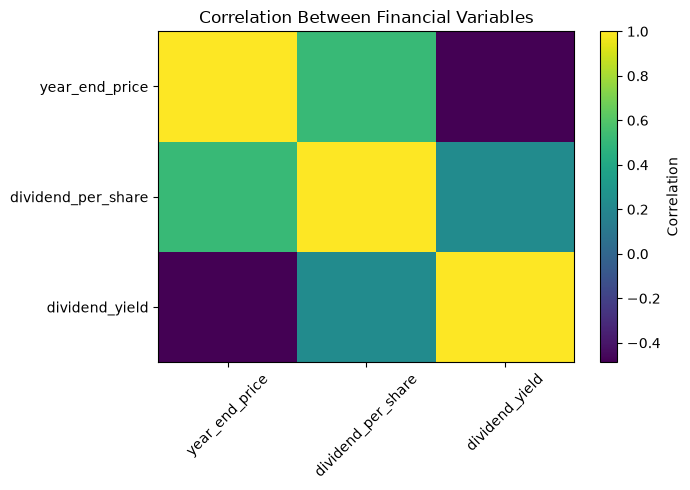

In [76]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Financial Variables")

plt.tight_layout()
plt.show()

In [77]:
highest_yield = (
    data.groupby("ticker")["dividend_yield"]
    .mean()
    .sort_values(ascending=False)
)

print("Highest average dividend yield:")
print(highest_yield.head(3))

Highest average dividend yield:
ticker
VZ     5.230909
XOM    4.385455
KO     3.056364
Name: dividend_yield, dtype: float64


In [78]:
highest_dividend = (
    data.groupby("ticker")["dividend_per_share"]
    .mean()
    .sort_values(ascending=False)
)

print("Highest average dividend per share:")
print(highest_dividend.head(3))

Highest average dividend per share:
ticker
MCD    5.084545
PEP    4.088364
JNJ    4.007273
Name: dividend_per_share, dtype: float64


In [79]:
highest_price = (
    data.groupby("ticker")["year_end_price"]
    .mean()
    .sort_values(ascending=False)
)

print("Highest average stock price:")
print(highest_price.head(3))

Highest average stock price:
ticker
MSFT    231.104547
MCD     220.488186
JNJ     149.634546
Name: year_end_price, dtype: float64


In [80]:
company_summary = (
    data.groupby(["company", "ticker"])
    .agg(
        average_price=("year_end_price", "mean"),
        average_dividend=("dividend_per_share", "mean"),
        average_yield=("dividend_yield", "mean")
    )
    .round(2)
    .sort_values("average_yield", ascending=False)
)

company_summary

,,average_price,average_dividend,average_yield
company,ticker,,,
Verizon,VZ,48.97,2.47,5.23
Exxon Mobil,XOM,84.58,3.42,4.39
Coca-Cola,KO,54.71,1.66,3.06
PepsiCo,PEP,139.97,4.09,2.93
Johnson & Johnson,JNJ,149.63,4.01,2.70
Procter & Gamble,PG,125.82,3.26,2.68
McDonald's,MCD,220.49,5.08,2.37
Walmart,WMT,49.54,0.74,1.82
Microsoft,MSFT,231.10,2.20,1.30


In [81]:
company_summary.to_csv(
    "../datasets/processed/company_summary.csv"
)

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
data = pd.read_csv(
    "../datasets/processed/dividend_analysis_clean.csv"
)

data.head()

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield
0,Apple,AAPL,2015,26.315001,0.5075,1.93
1,Apple,AAPL,2016,28.955000,0.5575,1.93
2,Apple,AAPL,2017,42.307499,0.6150,1.45
3,Apple,AAPL,2018,39.435001,0.7050,1.79
4,Apple,AAPL,2019,73.412498,0.7600,1.04


In [84]:
data = data.sort_values(
    ["ticker", "year"]
).reset_index(drop=True)

data.head(15)

,company,ticker,year,year_end_price,dividend_per_share,dividend_yield
0,Apple,AAPL,2015,26.315001,0.5075,1.93
1,Apple,AAPL,2016,28.955000,0.5575,1.93
2,Apple,AAPL,2017,42.307499,0.6150,1.45
3,Apple,AAPL,2018,39.435001,0.7050,1.79
4,Apple,AAPL,2019,73.412498,0.7600,1.04
5,Apple,AAPL,2020,132.690002,0.8075,0.61
6,Apple,AAPL,2021,177.570007,0.8650,0.49
7,Apple,AAPL,2022,129.929993,0.9100,0.70
8,Apple,AAPL,2023,192.529999,0.9500,0.49
9,Apple,AAPL,2024,250.419998,0.9900,0.40


In [85]:
data["dividend_growth"] = (
    data.groupby("ticker")["dividend_per_share"]
    .pct_change() * 100
)

In [86]:
data[
    [
        "ticker",
        "year",
        "dividend_per_share",
        "dividend_growth"
    ]
].head(20)

,ticker,year,dividend_per_share,dividend_growth
0,AAPL,2015,0.5075,NaN
1,AAPL,2016,0.5575,9.852217
2,AAPL,2017,0.6150,10.313901
3,AAPL,2018,0.7050,14.634146
4,AAPL,2019,0.7600,7.801418
5,AAPL,2020,0.8075,6.250000
6,AAPL,2021,0.8650,7.120743
7,AAPL,2022,0.9100,5.202312
8,AAPL,2023,0.9500,4.395604
9,AAPL,2024,0.9900,4.210526


In [87]:
data["price_growth"] = (
    data.groupby("ticker")["year_end_price"]
    .pct_change() * 100
)

In [88]:
data["annual_stock_return"] = data["price_growth"]

In [89]:
data["total_return"] = (
    data["annual_stock_return"]
    + data["dividend_yield"]
)

In [90]:
data[
    [
        "ticker",
        "year",
        "dividend_per_share",
        "dividend_growth",
        "year_end_price",
        "annual_stock_return",
        "dividend_yield",
        "total_return"
    ]
].head(20)

,ticker,year,dividend_per_share,dividend_growth,year_end_price,annual_stock_return,dividend_yield,total_return
0,AAPL,2015,0.5075,NaN,26.315001,NaN,1.93,NaN
1,AAPL,2016,0.5575,9.852217,28.955000,10.032298,1.93,11.962298
2,AAPL,2017,0.6150,10.313901,42.307499,46.114657,1.45,47.564657
3,AAPL,2018,0.7050,14.634146,39.435001,-6.789571,1.79,-4.999571
4,AAPL,2019,0.7600,7.801418,73.412498,86.160761,1.04,87.200761
5,AAPL,2020,0.8075,6.250000,132.690002,80.745793,0.61,81.355793
6,AAPL,2021,0.8650,7.120743,177.570007,33.823200,0.49,34.313200
7,AAPL,2022,0.9100,5.202312,129.929993,-26.828863,0.70,-26.128863
8,AAPL,2023,0.9500,4.395604,192.529999,48.179797,0.49,48.669797
9,AAPL,2024,0.9900,4.210526,250.419998,30.068041,0.40,30.468041


In [91]:
data[
    [
        "dividend_growth",
        "price_growth",
        "annual_stock_return",
        "total_return"
    ]
] = data[
    [
        "dividend_growth",
        "price_growth",
        "annual_stock_return",
        "total_return"
    ]
].round(2)

In [92]:
average_dividend_growth = (
    data.groupby("ticker")["dividend_growth"]
    .mean()
    .sort_values(ascending=False)
)

average_dividend_growth

ticker
MSFT    10.185
MCD      7.650
PEP      7.385
AAPL     7.381
JNJ      5.713
PG       4.746
KO       4.457
WMT      3.772
XOM      3.355
VZ       2.090
Name: dividend_growth, dtype: float64

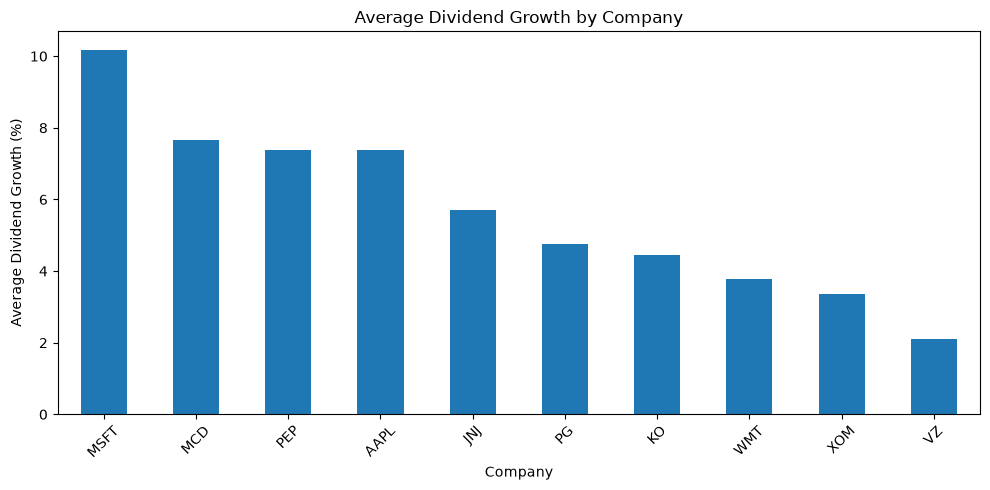

In [93]:
average_dividend_growth.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Dividend Growth by Company")
plt.xlabel("Company")
plt.ylabel("Average Dividend Growth (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
average_stock_return = (
    data.groupby("ticker")["annual_stock_return"]
    .mean()
    .sort_values(ascending=False)
)

average_stock_return

ticker
AAPL    31.006
MSFT    27.085
WMT     20.364
MCD     10.644
XOM      9.020
JNJ      8.277
PG       6.928
KO       5.233
PEP      4.272
VZ      -0.636
Name: annual_stock_return, dtype: float64

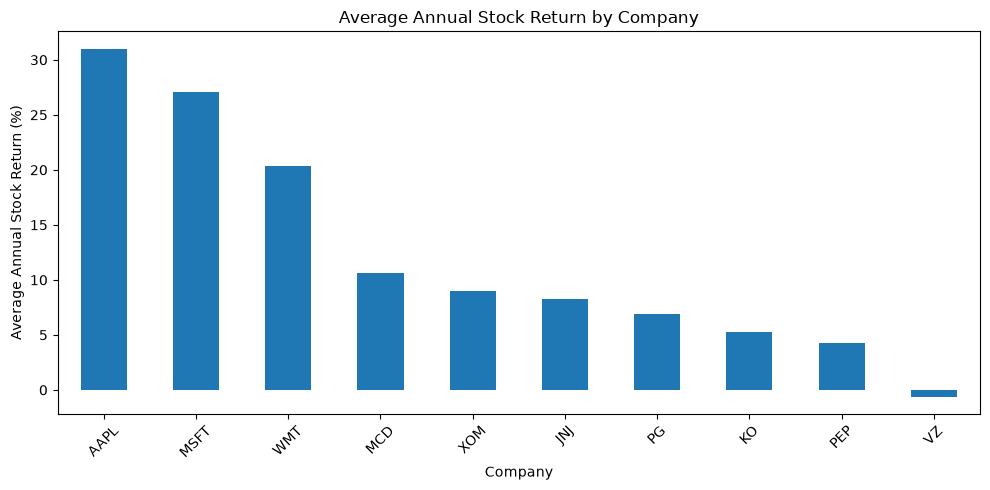

In [95]:
average_stock_return.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Annual Stock Return by Company")
plt.xlabel("Company")
plt.ylabel("Average Annual Stock Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

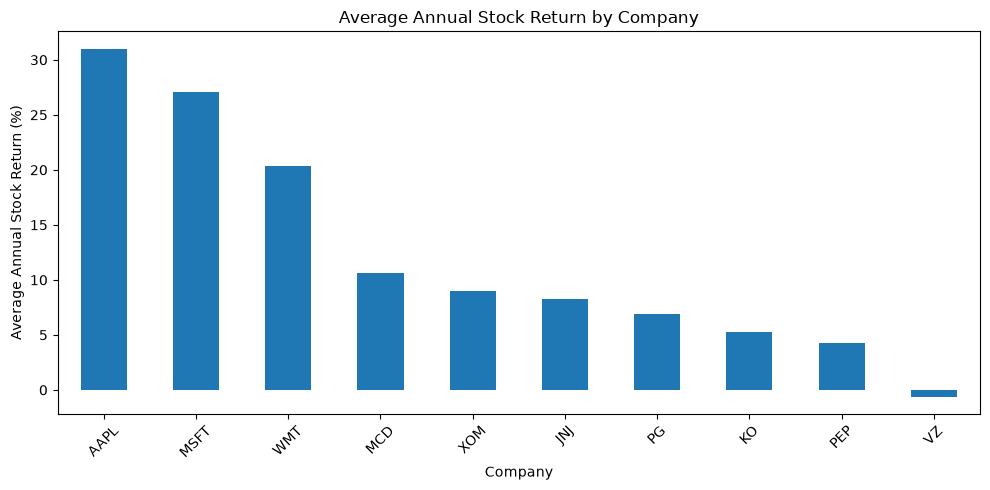

In [96]:
average_stock_return.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Annual Stock Return by Company")
plt.xlabel("Company")
plt.ylabel("Average Annual Stock Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [97]:
average_total_return = (
    data.groupby("ticker")["total_return"]
    .mean()
    .sort_values(ascending=False)
)

average_total_return

ticker
AAPL    31.934
MSFT    28.282
WMT     22.042
XOM     13.475
MCD     12.964
JNJ     10.957
PG       9.543
KO       8.288
PEP      7.222
VZ       4.639
Name: total_return, dtype: float64

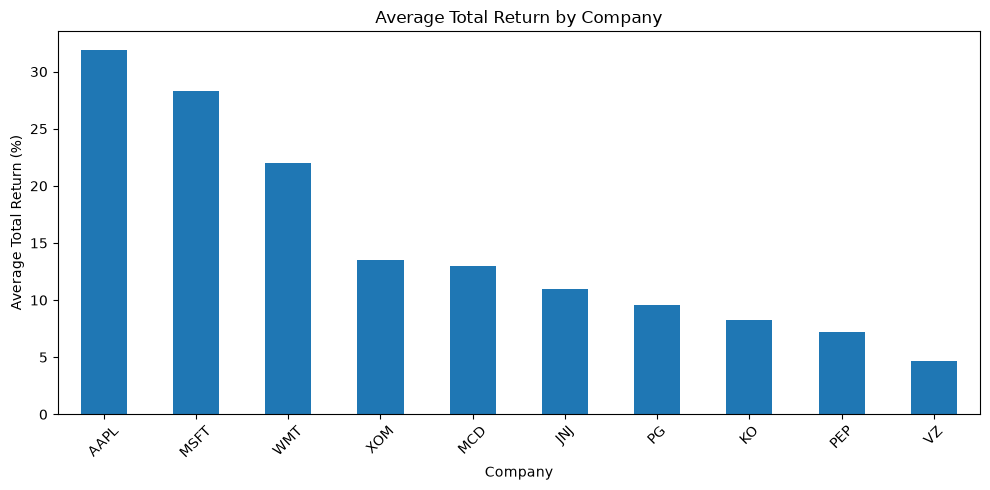

In [98]:
average_total_return.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Total Return by Company")
plt.xlabel("Company")
plt.ylabel("Average Total Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [99]:
comparison = (
    data.groupby("ticker")
    .agg(
        average_dividend_growth=("dividend_growth", "mean"),
        average_stock_return=("annual_stock_return", "mean"),
        average_dividend_yield=("dividend_yield", "mean"),
        average_total_return=("total_return", "mean")
    )
    .round(2)
)

comparison

,average_dividend_growth,average_stock_return,average_dividend_yield,average_total_return
ticker,,,,
AAPL,7.38,31.01,1.02,31.93
JNJ,5.71,8.28,2.70,10.96
KO,4.46,5.23,3.06,8.29
MCD,7.65,10.64,2.37,12.96
MSFT,10.18,27.08,1.30,28.28
PEP,7.38,4.27,2.93,7.22
PG,4.75,6.93,2.68,9.54
VZ,2.09,-0.64,5.23,4.64
WMT,3.77,20.36,1.82,22.04


In [100]:
correlation = data[
    [
        "dividend_growth",
        "annual_stock_return"
    ]
].corr()

correlation

,dividend_growth,annual_stock_return
dividend_growth,1.00000,0.14203
annual_stock_return,0.14203,1.00000


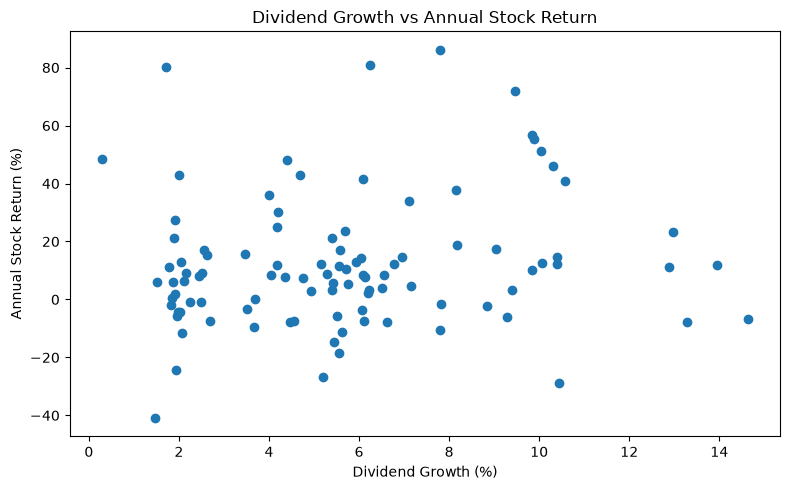

In [101]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data["dividend_growth"],
    data["annual_stock_return"]
)

plt.title(
    "Dividend Growth vs Annual Stock Return"
)

plt.xlabel("Dividend Growth (%)")
plt.ylabel("Annual Stock Return (%)")

plt.tight_layout()
plt.show()

In [102]:
print(
    "Top companies by average dividend growth:"
)

print(
    average_dividend_growth.head(5)
)

Top companies by average dividend growth:
ticker
MSFT    10.185
MCD      7.650
PEP      7.385
AAPL     7.381
JNJ      5.713
Name: dividend_growth, dtype: float64


In [103]:
print(
    "Top companies by average stock return:"
)

print(
    average_stock_return.head(5)
)

Top companies by average stock return:
ticker
AAPL    31.006
MSFT    27.085
WMT     20.364
MCD     10.644
XOM      9.020
Name: annual_stock_return, dtype: float64


In [104]:
data.to_csv(
    "../datasets/processed/dividend_return_analysis.csv",
    index=False
)

In [105]:
comparison.to_csv(
    "../datasets/processed/dividend_return_company_comparison.csv"
)